In [1]:
# Installing requires packages
# install.packages(c("RSQLite","dplyr","DBI","ggplot2", "stringr", "paletteer", "scales",
#                    "forcats", "knitr"))
# install.packages("svglite")


# Load required libraries
library(RSQLite)
library(dplyr)
library(DBI)
library(stringr)
library(ggplot2)
library(paletteer)
library(scales)
library(forcats)
library(knitr)
library(ggridges)
library(svglite)
library(tidyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# Connecting to splicing database
db_path <- "/home/bia/LandscapeSplicingGrasses/data/grasses.db"
con <- dbConnect(RSQLite::SQLite(), dbname = db_path)

sra_metadata <- tbl(con, "sra_metadata") %>%
  collect()

dbDisconnect(con)

head(sra_metadata)

Warning message:
“Column `number_of_spots`: mixed type, first seen values of type integer, coercing other values of type string”
Warning message:
“Column `number_of_bases`: mixed type, first seen values of type integer64, coercing other values of type string”
Warning message:
“Column `pmid`: mixed type, first seen values of type string, coercing other values of type integer”


sra_id,strand_info,ncbi_expid,ncbi_biosample_id,ncbi_biosample_name,ncbi_bioproject_id,number_of_spots,number_of_bases,platform,species_name,species_cultivar,species_genotype,treatment,dev_stage,tissue,age,source_name,pmid,layout
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int64>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SRR29182581,NA,33021877,SAMN41534674,Plant sample from Setaria italica,PRJNA1116564,15626198,4719111796,Illumina NovaSeq 6000,Setaria italica,,,,seedling,seedling-shoot,2 weeks,,,PAIRED
SRR29182582,NA,33021876,SAMN41534673,Plant sample from Setaria italica,PRJNA1116564,19767946,5969919692,Illumina NovaSeq 6000,Setaria italica,,,,seedling,seedling-shoot,2 weeks,,,PAIRED
SRR28033230,NA,31968320,SAMN39979325,G7,PRJNA1077683,25341112,5634004152,Illumina HiSeq 3000,Setaria italica,Yugu1,,,,,,,,PAIRED
SRR28033231,NA,31968319,SAMN39979324,G7,PRJNA1077683,26260147,6078203843,Illumina HiSeq 3000,Setaria italica,Yugu1,,,,,,,,PAIRED
SRR28033232,NA,31968318,SAMN39979323,G6,PRJNA1077683,26578834,6156990963,Illumina HiSeq 3000,Setaria italica,Yugu1,,,,,,,,PAIRED
SRR28033233,NA,31968317,SAMN39979322,G6,PRJNA1077683,28400641,6462609551,Illumina HiSeq 3000,Setaria italica,Yugu1,,,,,,,,PAIRED


In [4]:
species_color_palette <- c(
    "Arabidopsis thaliana"         = "#20DE8B",
    "Zea mays"                     = "#FFDE8B",
    "Oryza sativa"                 = "#FFA88B",
    "Sorghum bicolor"              = "#FF6A8B",
    "Human - HG18"                 = "#b397f9",
    "Human - HG38"                 = "#4f15e3",
    "Arabidopsis thaliana (Ref.)"  = "#CCDE8B",
    "Zea mays (Ref.)"              = "#f8be2b"
)

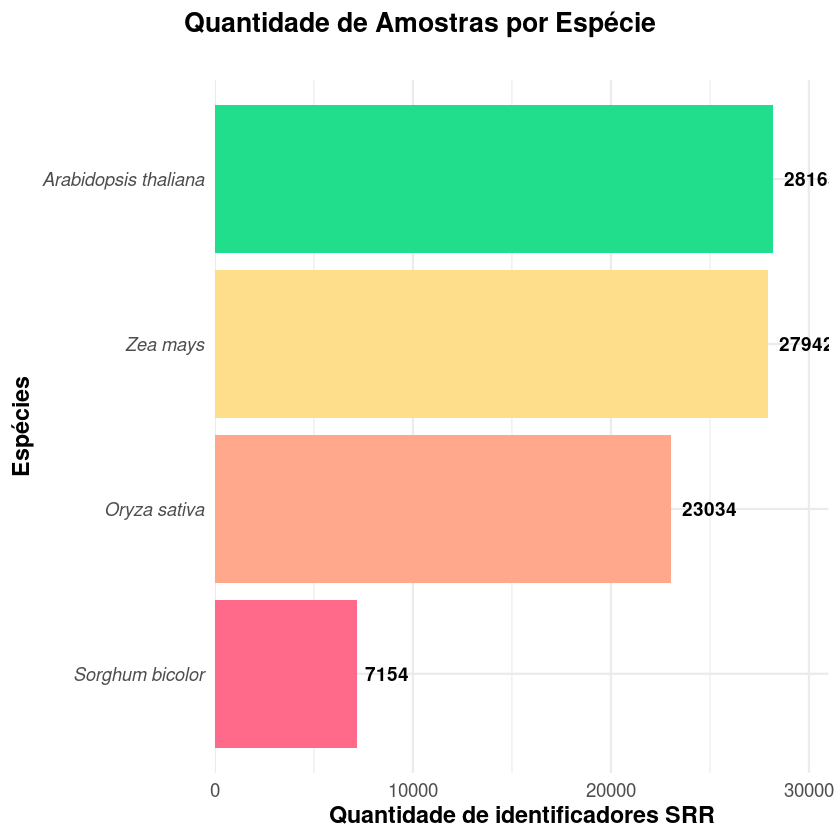

In [ ]:
title = "Quantidade de Amostras por Espécie"
subtitle = ""
y = "Quantidade de identificadores SRR"
x = "Espécies"
legend_title = ""

# Getting amount of SRR per species
srr_per_species <- sra_metadata %>%
  group_by(species_name) %>%
  summarise(n = n()) %>%
  arrange(desc(n))

# filtering species - A. thaliana, O. sativa, Z.mays, S. bicolor
srr_per_species <- srr_per_species %>%
  filter(species_name %in% c("Arabidopsis thaliana", "Oryza sativa", "Zea mays", "Sorghum bicolor"))

# Plotting the number of SRR per species horizontally
comparative_bar_chart <- ggplot(srr_per_species, aes(x = fct_reorder(species_name, n), y = n, fill = species_name)) +
  geom_col() + #
    scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +

  coord_flip() +
  geom_text(aes(label = n), hjust = -0.2, size = 4, fontface = "bold") +
  labs(title = title,
       subtitle = subtitle,
       x = x,
       y = y,
       fill = legend_title) +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11, face = "italic"),
        axis.title = element_text(face = "bold", size = 14),
        plot.title.position = "plot",
        plot.caption.position = "plot",
        axis.text.y = element_text(face = "italic", size = 11),
        legend.position = "none") +
  scale_fill_manual(values = species_color_palette)

ggsave(
  "grafico_srr_por_especie.png",  plot = comparative_bar_chart, width = 15, height = 8, dpi = 300)

comparative_bar_chart

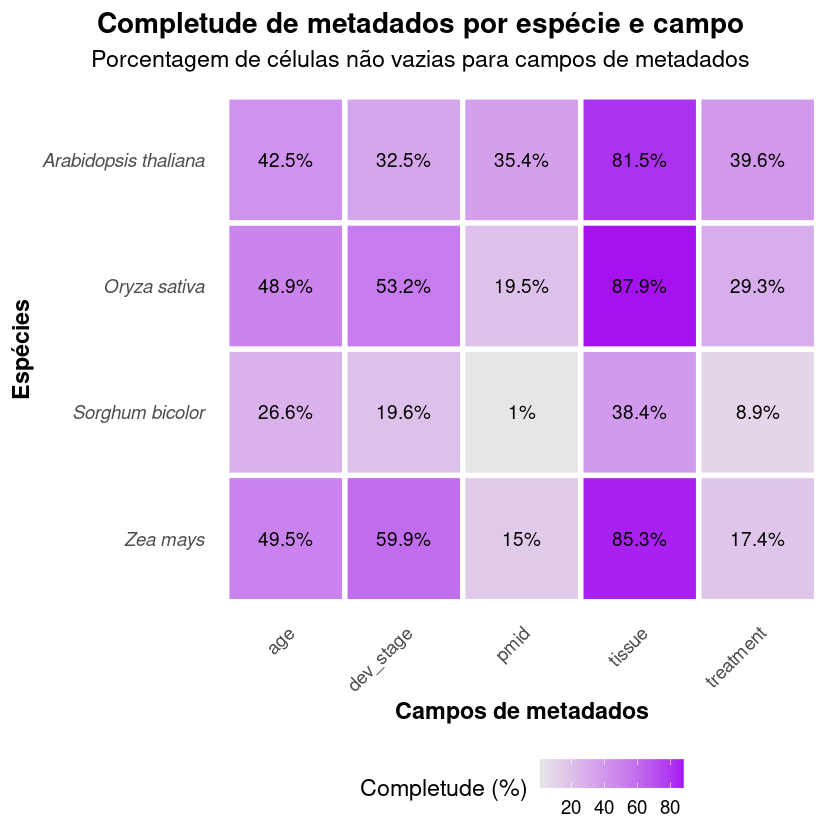

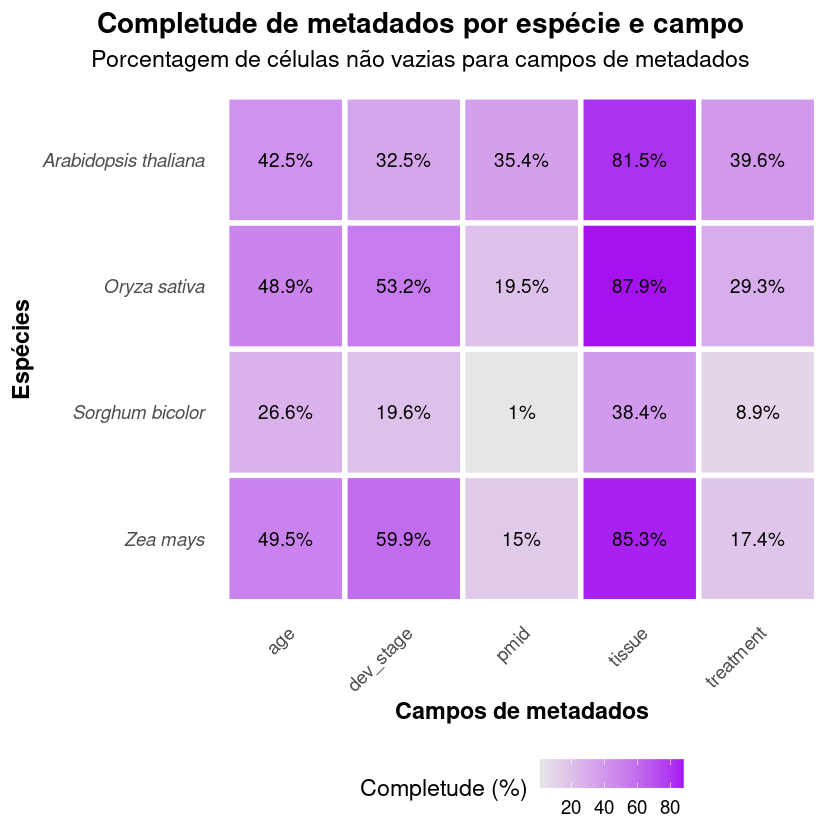

In [ ]:
title = "Completude de metadados por espécie e campo"
subtitle = "Porcentagem de células não vazias para campos de metadados"
y = "Espécies"
x = "Campos de metadados"
legend_title = ""

# Percentage of treatment, dev_stage, tissue, age, pmid cells filled species
metadata_columns <- c("treatment", "dev_stage", "tissue", "age", "pmid")

completeness_summary <- sra_metadata %>%
  filter(species_name %in% c("Arabidopsis thaliana", "Oryza sativa", "Zea mays", "Sorghum bicolor")) %>%
  group_by(species_name) %>%
    summarise(across(all_of(metadata_columns), 
                   ~ (sum(!is.na(.) & . != "") / n()) * 100),
            .groups = "drop") %>%
  
  pivot_longer(
    cols = all_of(metadata_columns),
    names_to = "metadata_field",
    values_to = "fill_percentage"
  ) %>%
  mutate(species_name = factor(species_name, levels = sort(unique(species_name), decreasing = TRUE)))


metadata_heatmap <- ggplot(
    completeness_summary, 
    aes(x = metadata_field, y = species_name, fill = fill_percentage)
  ) +
  geom_tile(color = "white", linewidth = 1.5) +
    geom_text(aes(label = paste0(round(fill_percentage, 1), "%")), color = "black", size = 4) +
    scale_fill_gradient(low = "#e6e6e6", high = "#A611F0", name = "Completude (%)") +
  
  labs(
    title = title,
    subtitle = subtitle,
    x = x,
    y = y
  ) +
  
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    plot.subtitle = element_text(hjust = 0.5),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.text.y = element_text(face = "italic"),
    legend.position = "bottom",
    plot.title.position = "plot",
    plot.caption.position = "plot",
    panel.grid = element_blank()
  )

ggsave(
  "metadata_heatmap.png", plot = metadata_heatmap, width = 10, height = 8, dpi = 300)

metadata_heatmap


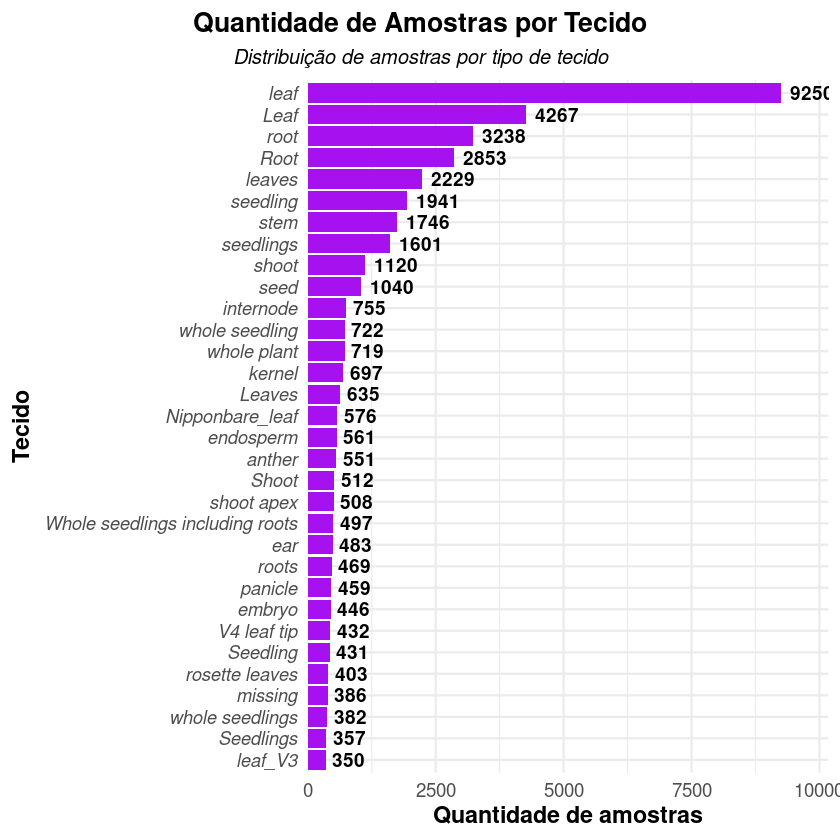

In [ ]:

tissue_counts <- sra_metadata %>%
    filter(species_name %in% c("Arabidopsis thaliana", "Oryza sativa", "Zea mays", "Sorghum bicolor")) %>%
    filter(!is.na(tissue) & tissue != "") %>%
    group_by(tissue) %>%
  summarise(count = n(), .groups = "drop") %>%
    arrange(desc(count)) %>%
    filter(count >= 350) %>%
    mutate(tissue = fct_reorder(tissue, count)) 

# Create a bar chart for tissue counts
tissue_bar_chart <- ggplot(tissue_counts, aes(x = fct_reorder(tissue, count), y = count, fill = tissue)) +
  geom_col(fill = "#A611F0") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  coord_flip() +
  geom_text(aes(label = count), hjust = -0.2, size = 4, fontface = "bold") +
  labs(title = "Quantidade de Amostras por Tecido",
       subtitle = "Distribuição de amostras por tipo de tecido",
       x = "Tecido",
       y = "Quantidade de amostras",
       fill = "Tecido") +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11, face = "italic"),
        axis.title = element_text(face = "bold", size = 14),
        plot.title.position = "plot",
        plot.caption.position = "plot",
        axis.text.y = element_text(face = "italic", size = 11),
        legend.position = "none") 

tissue_bar_chart

ggsave(
  "tissue_bar_all_chart.png", plot = tissue_bar_chart, width = 8, height = 10, dpi = 300)

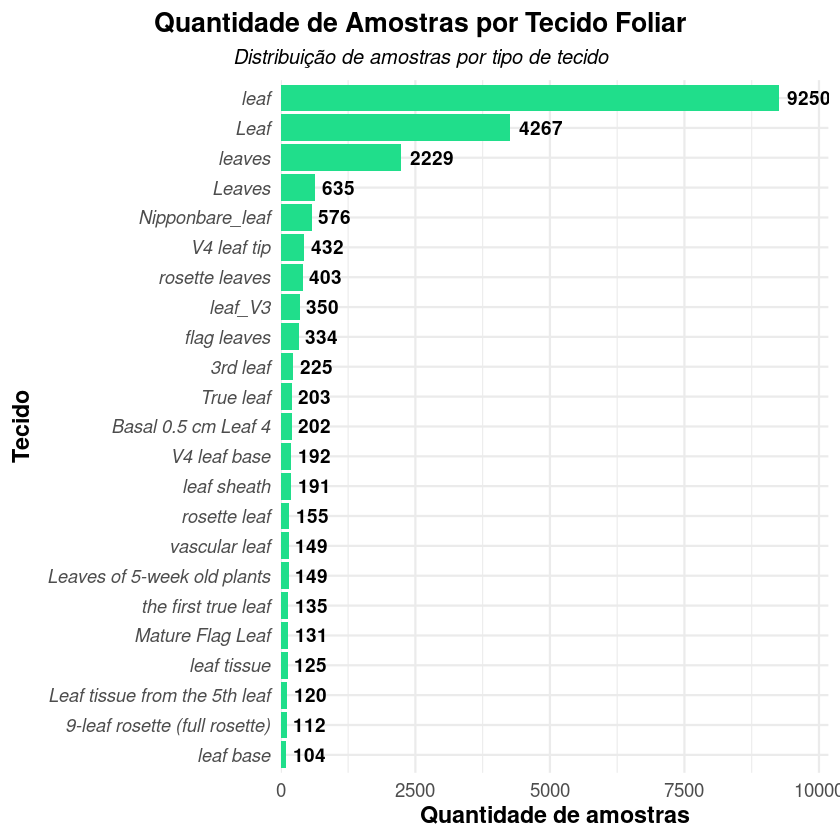

In [ ]:

tissue_counts <- sra_metadata %>%
    filter(species_name %in% c("Arabidopsis thaliana", "Oryza sativa", "Zea mays", "Sorghum bicolor")) %>%
    filter(!is.na(tissue) & tissue != "") %>%
    filter(str_detect(tissue, regex("leaf|leave", ignore_case = TRUE))) %>%
    group_by(tissue) %>%
  summarise(count = n(), .groups = "drop") %>%
    arrange(desc(count)) %>%
    filter(count >= 100) %>%
    mutate(tissue = fct_reorder(tissue, count))

# Create a bar chart for tissue counts
tissue_bar_chart <- ggplot(tissue_counts, aes(x = fct_reorder(tissue, count), y = count, fill = tissue)) +
  geom_col(fill = "#20DE8B") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  coord_flip() +
  geom_text(aes(label = count), hjust = -0.2, size = 4, fontface = "bold") +
  labs(title = "Quantidade de Amostras por Tecido Foliar",
       subtitle = "Distribuição de amostras por tipo de tecido",
       x = "Tecido",
       y = "Quantidade de amostras",
       fill = "Tecido") +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11, face = "italic"),
        axis.title = element_text(face = "bold", size = 14),
        plot.title.position = "plot",
        plot.caption.position = "plot",
        axis.text.y = element_text(face = "italic", size = 11),
        legend.position = "none") 

tissue_bar_chart

ggsave(
  "tissue_bar_chart.png", plot = tissue_bar_chart, width = 8, height = 10, dpi = 300)

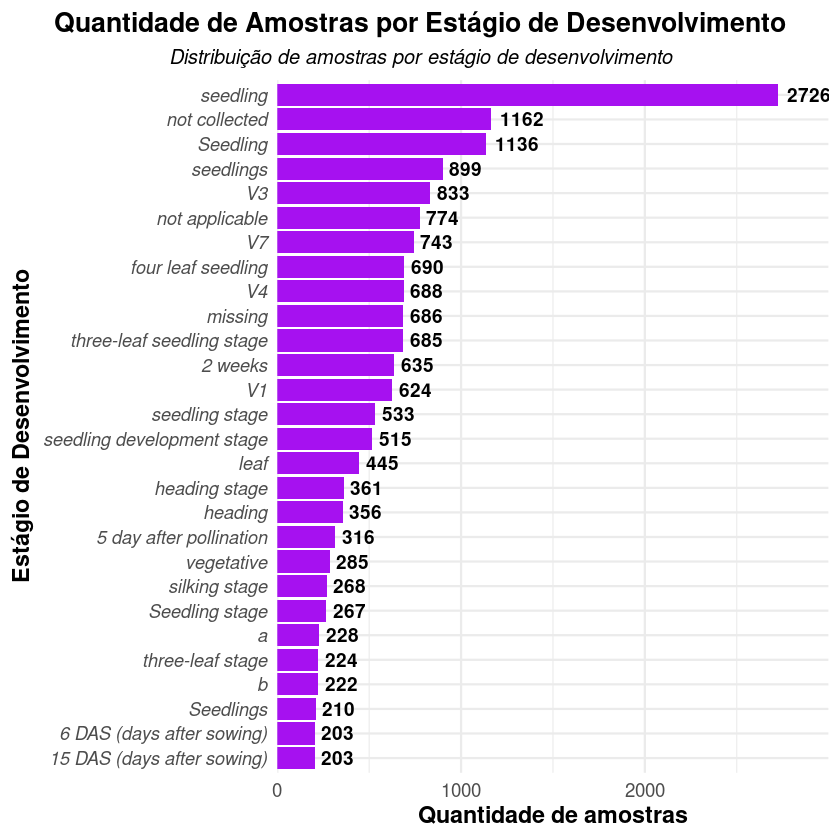

In [ ]:
# Amount of same values in dev_stage column 

dev_stage_counts <- sra_metadata %>%
    filter(species_name %in% c("Arabidopsis thaliana", "Oryza sativa", "Zea mays", "Sorghum bicolor")) %>%
    filter(!is.na(dev_stage) & dev_stage != "") %>%
    group_by(dev_stage) %>%
  summarise(count = n(), .groups = "drop") %>%
    arrange(desc(count)) %>%
    filter(count >= 200) %>%
    mutate(dev_stage = fct_reorder(dev_stage, count)) 

dev_stage_bar_chart <- ggplot(dev_stage_counts, aes(x = fct_reorder(dev_stage, count), y = count, fill = dev_stage)) +
  geom_col(fill = "#A611F0") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  coord_flip() +
  geom_text(aes(label = count), hjust = -0.2, size = 4, fontface = "bold") +
  labs(title = "Quantidade de Amostras por Estágio de Desenvolvimento",
       subtitle = "Distribuição de amostras por estágio de desenvolvimento",
       x = "Estágio de Desenvolvimento",
       y = "Quantidade de amostras",
       fill = "estágio de desenvolvimento") +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11, face = "italic"),
        axis.title = element_text(face = "bold", size = 14),
        plot.title.position = "plot",
        plot.caption.position = "plot",
        axis.text.y = element_text(face = "italic", size = 11),
        legend.position = "none") 

dev_stage_bar_chart

ggsave(
  "dev_stage_bar_chart.png", plot = dev_stage_bar_chart,width = 8, height = 10, dpi = 300)

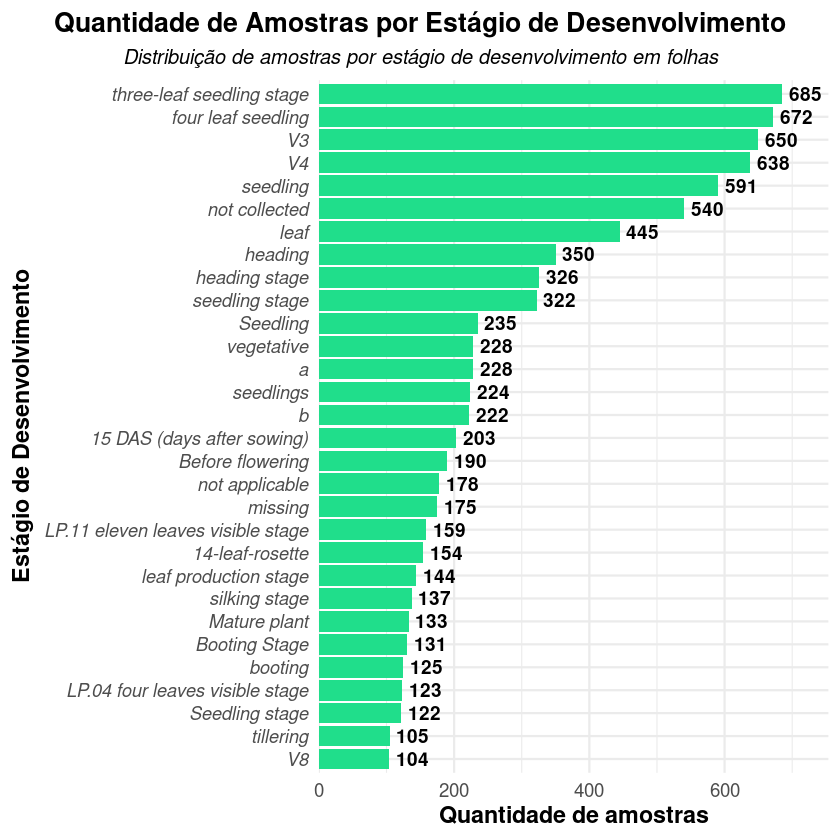

In [ ]:
# Amount of same values in dev_stage column for leave/leaf

dev_stage_counts <- sra_metadata %>%
    filter(species_name %in% c("Arabidopsis thaliana", "Oryza sativa", "Zea mays", "Sorghum bicolor")) %>%
    filter(str_detect(tissue, regex("leaf|leave", ignore_case = TRUE))) %>%
    filter(!is.na(dev_stage) & dev_stage != "") %>%
    group_by(dev_stage) %>%
  summarise(count = n(), .groups = "drop") %>%
    arrange(desc(count)) %>%
    filter(count >= 100) %>%
    mutate(dev_stage = fct_reorder(dev_stage, count))

# Create a bar chart for dev_stage counts
dev_stage_leaf_bar_chart <- ggplot(dev_stage_counts, aes(x = fct_reorder(dev_stage, count), y = count, fill = dev_stage)) +
  geom_col(fill = "#20DE8B") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  coord_flip() +
  geom_text(aes(label = count), hjust = -0.2, size = 4, fontface = "bold") +
  labs(title = "Quantidade de Amostras por Estágio de Desenvolvimento",
       subtitle = "Distribuição de amostras por estágio de desenvolvimento em folhas",
       x = "Estágio de Desenvolvimento",
       y = "Quantidade de amostras",
       fill = "estágio de desenvolvimento") +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11, face = "italic"),
        axis.title = element_text(face = "bold", size = 14),
        plot.title.position = "plot",
        plot.caption.position = "plot",
        axis.text.y = element_text(face = "italic", size = 11),
        legend.position = "none") 

dev_stage_leaf_bar_chart

ggsave(
  "dev_stage_bar_leaf_chart.png", plot = dev_stage_leaf_bar_chart, width = 8, height = 10, dpi = 300)

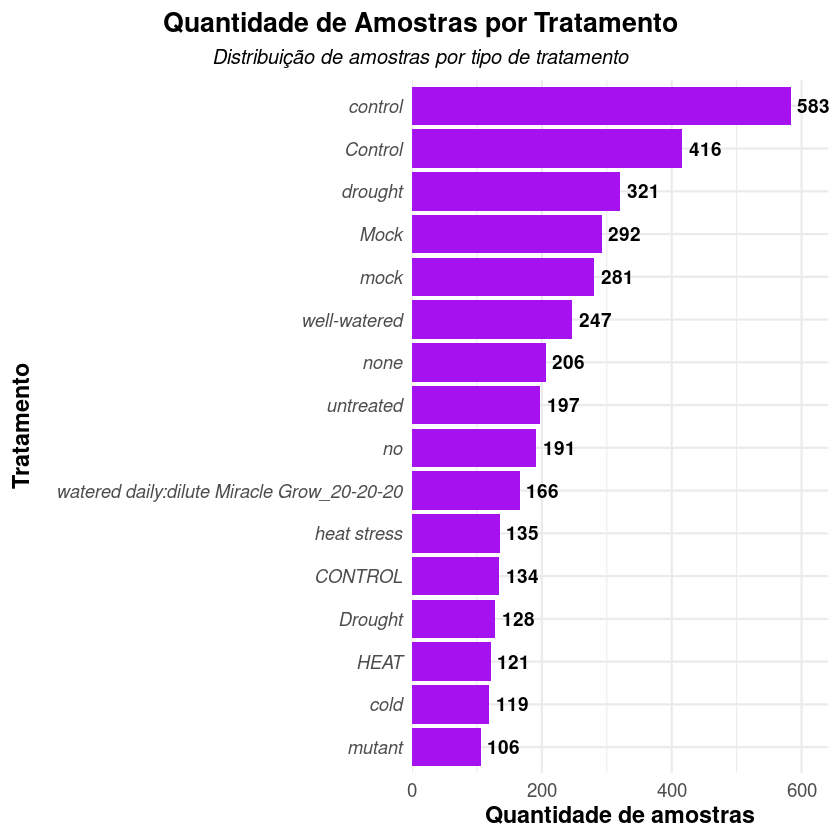

In [ ]:
# Amount of same values in treatment column

treatment_counts <- sra_metadata %>%
    filter(species_name %in% c("Arabidopsis thaliana", "Oryza sativa", "Zea mays", "Sorghum bicolor")) %>%
    filter(!is.na(treatment) & treatment != "") %>%
    group_by(treatment) %>%
  summarise(count = n(), .groups = "drop") %>%
    arrange(desc(count)) %>%
    filter(count >= 100) %>%
    mutate(treatment = fct_reorder(treatment, count)) 

# Create a bar chart for treatment counts
treatment_bar_chart <- ggplot(treatment_counts, aes(x = fct_reorder(treatment, count), y = count, fill = treatment)) +
  geom_col(fill = "#A611F0") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  coord_flip() +
  geom_text(aes(label = count), hjust = -0.2, size = 4, fontface = "bold") +
  labs(title = "Quantidade de Amostras por Tratamento",
       subtitle = "Distribuição de amostras por tipo de tratamento",
       x = "Tratamento",
       y = "Quantidade de amostras",
       fill = "Tratamento") +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11, face = "italic"),
        axis.title = element_text(face = "bold", size = 14),
        plot.title.position = "plot",
        plot.caption.position = "plot",
        axis.text.y = element_text(face = "italic", size = 11),
        legend.position = "none")

treatment_bar_chart

ggsave(
  "treatment_bar_chart.png", plot = treatment_bar_chart, width = 8, height = 10, dpi = 300)


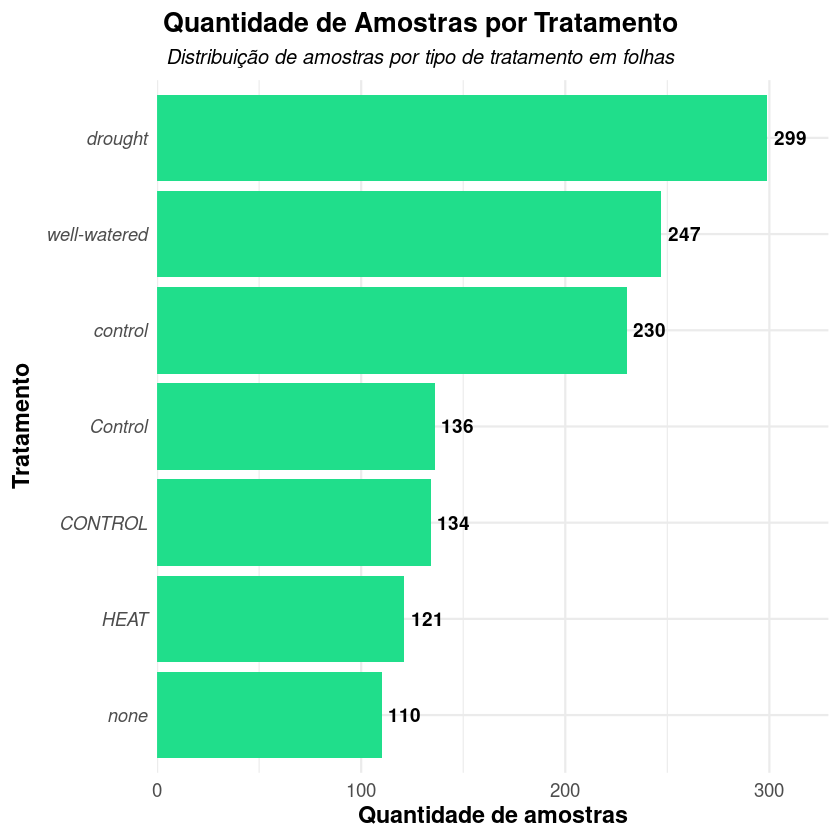

In [ ]:
# Amount of same values in treatment column for leave/leaf

treatment_counts <- sra_metadata %>%
    filter(species_name %in% c("Arabidopsis thaliana", "Oryza sativa", "Zea mays", "Sorghum bicolor")) %>%
    filter(str_detect(tissue, regex("leaf|leave", ignore_case = TRUE))) %>%
    filter(!is.na(treatment) & treatment != "") %>%
    group_by(treatment) %>%
  summarise(count = n(), .groups = "drop") %>%
    arrange(desc(count)) %>%
    filter(count >= 100) %>%
    mutate(treatment = fct_reorder(treatment, count))

# Create a bar chart for treatment counts
treatment_leaf_bar_chart <- ggplot(treatment_counts, aes(x = fct_reorder(treatment, count), y = count, fill = treatment)) +
  geom_col(fill = "#20DE8B") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  coord_flip() +
  geom_text(aes(label = count), hjust = -0.2, size = 4, fontface = "bold") +
  labs(title = "Quantidade de Amostras por Tratamento",
       subtitle = "Distribuição de amostras por tipo de tratamento em folhas",
       x = "Tratamento",
       y = "Quantidade de amostras",
       fill = "Tratamento") +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11, face = "italic"),
        axis.title = element_text(face = "bold", size = 14),
        plot.title.position = "plot",
        plot.caption.position = "plot",
        axis.text.y = element_text(face = "italic", size = 11),
        legend.position = "none")

treatment_leaf_bar_chart

ggsave(
  "treatment_bar_leaf_chart.png", plot = treatment_leaf_bar_chart, width = 8, height = 10, dpi = 300)